# Comparacao qualidade x tempo: MCTS base vs MCTS com heuristicas

Este notebook compara duas versoes da MCTS para PopOut, para conferirmos a melhoria gerada pelas mudanças no algoritmo base do popout:

- **MCTS base**: `src.mcts.mcts_service_mock.MCTS`, com UCT puro e rollouts aleatorios.
- **MCTS heuristica**: `src.mcts.mcts_service.MCTS`, com prior heuristico e rollout tatico.

A qualidade e medida por **score rate** em confronto direto: vitoria = 1, empate = 0.5, derrota = 0. O tempo e medido por chamada a `search()`.

## 1. Imports

In [2]:
from pathlib import Path
from time import perf_counter
import random
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pop_out import BLUE_PLAYER, RED_PLAYER, PopOut
from src.mcts.mcts_service import MCTS as HeuristicMCTS
from src.mcts.mcts_service_mock import MCTS as BaseMCTS

## 2. Configuracao do benchmark

A lista abaixo ja inclui os valores pedidos. Para um resultado final mais estavel, aumente `GAMES_PER_PAIRING`; isso cresce rapidamente com `1000+` iteracoes.

In [3]:
ITERATIONS = [50, 100, 300, 500, 1000, 2000]

# Cada pairing roda 4 jogos por repeticao:
# base vermelho / heuristica azul, com cada lado comecando uma vez;
# heuristica vermelho / base azul, com cada lado comecando uma vez.
GAMES_PER_PAIRING = 3

ROLLOUT_LIMIT = 500
MAX_PLIES = 140
SEED = 42

AGENT_CLASSES = {
    "MCTS base": BaseMCTS,
    "MCTS heuristica": HeuristicMCTS,
}

MATCH_SCHEDULE = [
    ("MCTS base", "MCTS heuristica", RED_PLAYER),
    ("MCTS base", "MCTS heuristica", BLUE_PLAYER),
    ("MCTS heuristica", "MCTS base", RED_PLAYER),
    ("MCTS heuristica", "MCTS base", BLUE_PLAYER),
]

## 3. Funcoes auxiliares

In [7]:
def new_game(starting_player):
    game = PopOut()
    game.turn = starting_player
    game.last_player = None
    game.game_drawn = False
    return game


def empty_agent_stats():
    return {
        "games": 0,
        "score": 0.0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "searches": 0,
        "search_time_s": 0.0,
    }


def play_game(iterations, red_agent_name, blue_agent_name, starting_player):
    game = new_game(starting_player)
    player_to_agent_name = {
        RED_PLAYER: red_agent_name,
        BLUE_PLAYER: blue_agent_name,
    }
    agents = {
        RED_PLAYER: AGENT_CLASSES[red_agent_name](
            iterations=iterations,
            rollout_limit=ROLLOUT_LIMIT,
        ),
        BLUE_PLAYER: AGENT_CLASSES[blue_agent_name](
            iterations=iterations,
            rollout_limit=ROLLOUT_LIMIT,
        ),
    }
    stats = {name: empty_agent_stats() for name in AGENT_CLASSES}
    plies = 0 # Nro de jogadas de cada jogador (numero de jogadas individuais)

    while not game.is_terminal() and plies < MAX_PLIES:
        current_player = game.turn
        agent_name = player_to_agent_name[current_player]
        agent = agents[current_player]

        start = perf_counter()
        move = agent.search(game)
        elapsed = perf_counter() - start

        stats[agent_name]["searches"] += 1
        stats[agent_name]["search_time_s"] += elapsed

        if move is None:
            break

        game.apply_move(move)
        plies += 1

    winner = None if plies >= MAX_PLIES else game.check_winner()
    winner_agent_name = None
    if winner in player_to_agent_name:
        winner_agent_name = player_to_agent_name[winner]

    for agent_name in AGENT_CLASSES:
        stats[agent_name]["games"] += 1
        if winner_agent_name is None:
            stats[agent_name]["score"] += 0.5
            stats[agent_name]["draws"] += 1
        elif agent_name == winner_agent_name:
            stats[agent_name]["score"] += 1.0
            stats[agent_name]["wins"] += 1
        else:
            stats[agent_name]["losses"] += 1

    return {
        "iterations": iterations,
        "red_agent": red_agent_name,
        "blue_agent": blue_agent_name,
        "starting_player": "red" if starting_player == RED_PLAYER else "blue",
        "winner": winner_agent_name or "draw",
        "plies": plies,
        "stats": stats,
    }

## 4. Executar benchmark

In [10]:
match_records = []
summary_records = []

for iterations in ITERATIONS:
    totals = {name: empty_agent_stats() for name in AGENT_CLASSES}
    print(f"Running {iterations} iterations...")

    for repeat in range(GAMES_PER_PAIRING):
        for schedule_index, (red_agent, blue_agent, starter) in enumerate(MATCH_SCHEDULE):
            random.seed(SEED + iterations * 10_000 + repeat * 100 + schedule_index)
            result = play_game(iterations, red_agent, blue_agent, starter)
            match_records.append(
                {key: value for key, value in result.items() if key != "stats"}
            )

            for agent_name, game_stats in result["stats"].items():
                for key, value in game_stats.items():
                    totals[agent_name][key] += value

    for agent_name, stats in totals.items():
        summary_records.append(
            {
                "iterations": iterations,
                "agent": agent_name,
                "games": stats["games"],
                "wins": stats["wins"],
                "draws": stats["draws"],
                "losses": stats["losses"],
                "score_rate": stats["score"] / stats["games"],
                "searches": stats["searches"],
                "total_search_time_s": stats["search_time_s"],
                "avg_time_per_move_s": (
                    stats["search_time_s"] / stats["searches"]
                    if stats["searches"]
                    else 0.0
                ),
            }
        )

matches_df = pd.DataFrame(match_records)
summary_df = pd.DataFrame(summary_records)

summary_df

Running 50 iterations...
Running 100 iterations...
Running 300 iterations...
Running 500 iterations...
Running 1000 iterations...
Running 2000 iterations...


,iterations,agent,games,wins,draws,losses,score_rate,searches,total_search_time_s,avg_time_per_move_s
0,50,MCTS base,12,2,0,10,0.166667,86,3.911657,0.045484
1,50,MCTS heuristica,12,10,0,2,0.833333,90,22.530261,0.250336
2,100,MCTS base,12,0,0,12,0.000000,102,7.415982,0.072706
3,100,MCTS heuristica,12,12,0,0,1.000000,108,44.156019,0.408852
4,300,MCTS base,12,3,0,9,0.250000,111,23.100597,0.208113
5,300,MCTS heuristica,12,9,0,3,0.750000,115,137.757037,1.197887
6,500,MCTS base,12,1,0,11,0.083333,87,30.743833,0.353377
7,500,MCTS heuristica,12,11,0,1,0.916667,92,160.738419,1.747157
8,1000,MCTS base,12,6,0,6,0.500000,111,75.100614,0.676582
9,1000,MCTS heuristica,12,6,0,6,0.500000,114,373.419317,3.275608


## 5. Resultados por jogo

In [11]:
matches_df

,iterations,red_agent,blue_agent,starting_player,winner,plies
0,50,MCTS base,MCTS heuristica,red,MCTS heuristica,12
1,50,MCTS base,MCTS heuristica,blue,MCTS heuristica,15
2,50,MCTS heuristica,MCTS base,red,MCTS heuristica,9
3,50,MCTS heuristica,MCTS base,blue,MCTS base,7
4,50,MCTS base,MCTS heuristica,red,MCTS heuristica,8
...,...,...,...,...,...,...
67,2000,MCTS heuristica,MCTS base,blue,MCTS heuristica,16
68,2000,MCTS base,MCTS heuristica,red,MCTS heuristica,16
69,2000,MCTS base,MCTS heuristica,blue,MCTS heuristica,7
70,2000,MCTS heuristica,MCTS base,red,MCTS heuristica,15


## 6. Grafico qualidade x tempo

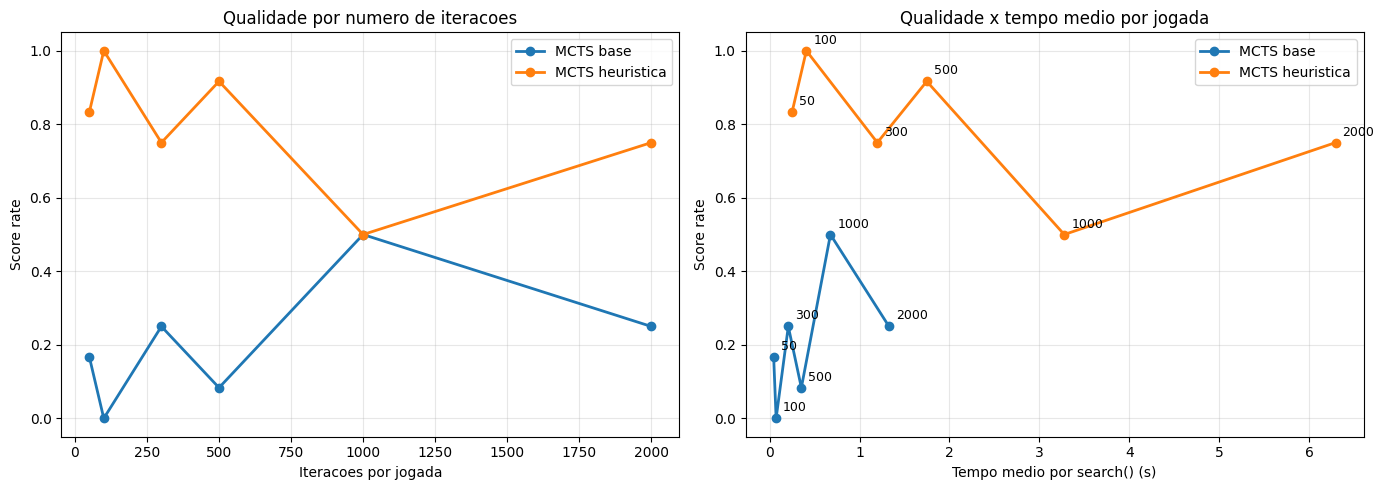

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for agent_name, group in summary_df.groupby("agent"):
    group = group.sort_values("iterations")
    axes[0].plot(
        group["iterations"],
        group["score_rate"],
        marker="o",
        linewidth=2,
        label=agent_name,
    )
    axes[1].plot(
        group["avg_time_per_move_s"],
        group["score_rate"],
        marker="o",
        linewidth=2,
        label=agent_name,
    )
    for _, row in group.iterrows():
        axes[1].annotate(
            str(int(row["iterations"])),
            (row["avg_time_per_move_s"], row["score_rate"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9,
        )

axes[0].set_title("Qualidade por numero de iteracoes")
axes[0].set_xlabel("Iteracoes por jogada")
axes[0].set_ylabel("Score rate")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Qualidade x tempo medio por jogada")
axes[1].set_xlabel("Tempo medio por search() (s)")
axes[1].set_ylabel("Score rate")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Guardar CSV e figura

In [13]:
output_dir = PROJECT_ROOT / "outputs"
output_dir.mkdir(exist_ok=True)

summary_path = output_dir / "mcts_quality_time_summary.csv"
matches_path = output_dir / "mcts_quality_time_matches.csv"
figure_path = output_dir / "mcts_quality_time.png"

summary_df.to_csv(summary_path, index=False)
matches_df.to_csv(matches_path, index=False)

fig.savefig(figure_path, dpi=160, bbox_inches="tight")

summary_path, matches_path, figure_path

(PosixPath('/home/bruno-zabot/Desktop/assignments/artificial-intelligence/outputs/mcts_quality_time_summary.csv'),
 PosixPath('/home/bruno-zabot/Desktop/assignments/artificial-intelligence/outputs/mcts_quality_time_matches.csv'),
 PosixPath('/home/bruno-zabot/Desktop/assignments/artificial-intelligence/outputs/mcts_quality_time.png'))

## 8. Caso com tempo parecido: heuristica 200 IT vs base 1500 IT

Esta secao compara diretamente dois agentes com tempos esperados proximos: **MCTS heuristica com 200 iteracoes** contra **MCTS base com 1500 iteracoes**. A estrutura do confronto e a mesma da analise anterior: alternamos as cores e o jogador inicial para reduzir vies de ordem.

In [33]:
ASYMMETRIC_AGENT_ITERATIONS = {
    "MCTS base": 1500,
    "MCTS heuristica": 200,
}
ASYMMETRIC_LABEL = "heuristica_200_vs_base_1500"
ASYMMETRIC_GAMES_PER_PAIRING = GAMES_PER_PAIRING


def play_game_asymmetric(agent_iterations, red_agent_name, blue_agent_name, starting_player):
    game = new_game(starting_player)
    player_to_agent_name = {
        RED_PLAYER: red_agent_name,
        BLUE_PLAYER: blue_agent_name,
    }
    agents = {
        RED_PLAYER: AGENT_CLASSES[red_agent_name](
            iterations=agent_iterations[red_agent_name],
            rollout_limit=ROLLOUT_LIMIT,
        ),
        BLUE_PLAYER: AGENT_CLASSES[blue_agent_name](
            iterations=agent_iterations[blue_agent_name],
            rollout_limit=ROLLOUT_LIMIT,
        ),
    }
    stats = {name: empty_agent_stats() for name in AGENT_CLASSES}
    plies = 0

    while not game.is_terminal() and plies < MAX_PLIES:
        current_player = game.turn
        agent_name = player_to_agent_name[current_player]
        agent = agents[current_player]

        start = perf_counter()
        move = agent.search(game)
        elapsed = perf_counter() - start

        stats[agent_name]["searches"] += 1
        stats[agent_name]["search_time_s"] += elapsed

        if move is None:
            break

        game.apply_move(move)
        plies += 1

    winner = None if plies >= MAX_PLIES else game.check_winner()
    winner_agent_name = None
    if winner in player_to_agent_name:
        winner_agent_name = player_to_agent_name[winner]

    for agent_name in AGENT_CLASSES:
        stats[agent_name]["games"] += 1
        if winner_agent_name is None:
            stats[agent_name]["score"] += 0.5
            stats[agent_name]["draws"] += 1
        elif agent_name == winner_agent_name:
            stats[agent_name]["score"] += 1.0
            stats[agent_name]["wins"] += 1
        else:
            stats[agent_name]["losses"] += 1

    return {
        "case": ASYMMETRIC_LABEL,
        "red_agent": red_agent_name,
        "red_iterations": agent_iterations[red_agent_name],
        "blue_agent": blue_agent_name,
        "blue_iterations": agent_iterations[blue_agent_name],
        "starting_player": "red" if starting_player == RED_PLAYER else "blue",
        "winner": winner_agent_name or "draw",
        "plies": plies,
        "stats": stats,
    }


### 8.1 Executar confronto assimetrico

In [34]:
asymmetric_match_records = []
asymmetric_summary_records = []
asymmetric_totals = {name: empty_agent_stats() for name in AGENT_CLASSES}

print(
    "Running same-time case: "
    f"heuristica {ASYMMETRIC_AGENT_ITERATIONS['MCTS heuristica']} IT vs "
    f"base {ASYMMETRIC_AGENT_ITERATIONS['MCTS base']} IT..."
)

for repeat in range(ASYMMETRIC_GAMES_PER_PAIRING):
    for schedule_index, (red_agent, blue_agent, starter) in enumerate(MATCH_SCHEDULE):
        random.seed(SEED + 9_000_000 + repeat * 100 + schedule_index)
        result = play_game_asymmetric(
            ASYMMETRIC_AGENT_ITERATIONS,
            red_agent,
            blue_agent,
            starter,
        )
        asymmetric_match_records.append(
            {key: value for key, value in result.items() if key != "stats"}
        )

        for agent_name, game_stats in result["stats"].items():
            for key, value in game_stats.items():
                asymmetric_totals[agent_name][key] += value

for agent_name, stats in asymmetric_totals.items():
    asymmetric_summary_records.append(
        {
            "case": ASYMMETRIC_LABEL,
            "agent": agent_name,
            "iterations": ASYMMETRIC_AGENT_ITERATIONS[agent_name],
            "games": stats["games"],
            "wins": stats["wins"],
            "draws": stats["draws"],
            "losses": stats["losses"],
            "score_rate": stats["score"] / stats["games"],
            "searches": stats["searches"],
            "total_search_time_s": stats["search_time_s"],
            "avg_time_per_move_s": (
                stats["search_time_s"] / stats["searches"]
                if stats["searches"]
                else 0.0
            ),
        }
    )

asymmetric_matches_df = pd.DataFrame(asymmetric_match_records)
asymmetric_summary_df = pd.DataFrame(asymmetric_summary_records).sort_values(
    ["agent", "iterations"]
)

asymmetric_summary_df

Running same-time case: heuristica 200 IT vs base 1500 IT...


,case,agent,iterations,games,wins,draws,losses,score_rate,searches,total_search_time_s,avg_time_per_move_s
0,heuristica_200_vs_base_1500,MCTS base,1500,12,6,0,6,0.5,100,137.965389,1.379654
1,heuristica_200_vs_base_1500,MCTS heuristica,200,12,6,0,6,0.5,101,100.932271,0.999329


### 8.2 Resultados por jogo

In [35]:
asymmetric_matches_df

,case,red_agent,red_iterations,blue_agent,blue_iterations,starting_player,winner,plies
0,heuristica_200_vs_base_1500,MCTS base,1500,MCTS heuristica,200,red,MCTS base,19
1,heuristica_200_vs_base_1500,MCTS base,1500,MCTS heuristica,200,blue,MCTS heuristica,33
2,heuristica_200_vs_base_1500,MCTS heuristica,200,MCTS base,1500,red,MCTS heuristica,15
3,heuristica_200_vs_base_1500,MCTS heuristica,200,MCTS base,1500,blue,MCTS base,30
4,heuristica_200_vs_base_1500,MCTS base,1500,MCTS heuristica,200,red,MCTS heuristica,18
5,heuristica_200_vs_base_1500,MCTS base,1500,MCTS heuristica,200,blue,MCTS heuristica,7
6,heuristica_200_vs_base_1500,MCTS heuristica,200,MCTS base,1500,red,MCTS heuristica,9
7,heuristica_200_vs_base_1500,MCTS heuristica,200,MCTS base,1500,blue,MCTS base,15
8,heuristica_200_vs_base_1500,MCTS base,1500,MCTS heuristica,200,red,MCTS base,15
9,heuristica_200_vs_base_1500,MCTS base,1500,MCTS heuristica,200,blue,MCTS heuristica,7


### 8.3 Grafico qualidade x tempo

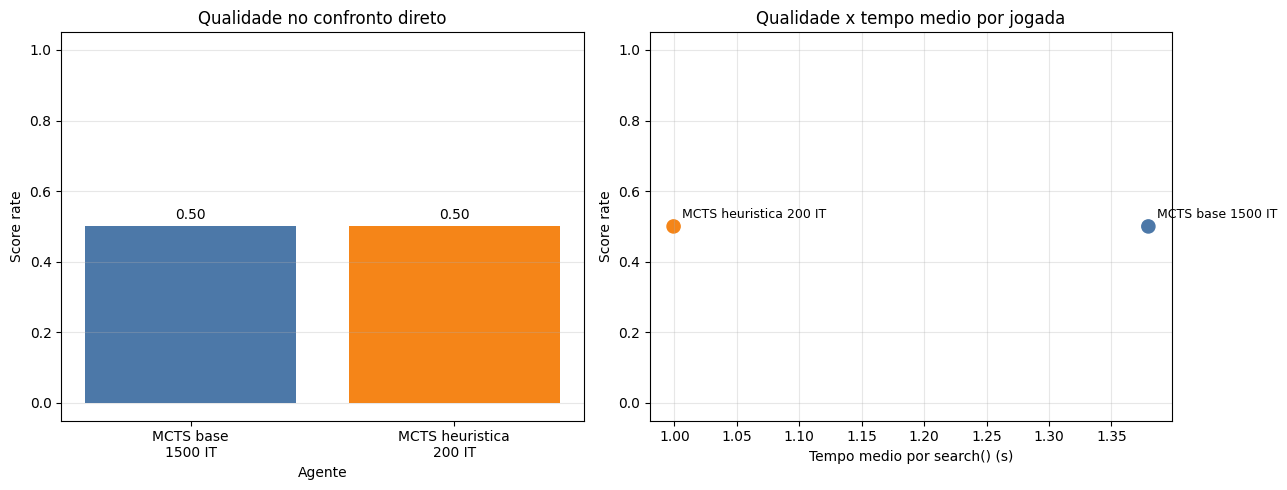

In [36]:
plot_df = asymmetric_summary_df.copy()
plot_df["label"] = plot_df.apply(
    lambda row: f"{row['agent']}\n{int(row['iterations'])} IT",
    axis=1,
)

fig_same_time, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(plot_df["label"], plot_df["score_rate"], color=["#4c78a8", "#f58518"])
axes[0].set_title("Qualidade no confronto direto")
axes[0].set_xlabel("Agente")
axes[0].set_ylabel("Score rate")
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, axis="y", alpha=0.3)

for index, row in plot_df.reset_index(drop=True).iterrows():
    axes[0].annotate(
        f"{row['score_rate']:.2f}",
        (index, row["score_rate"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
    )

axes[1].scatter(
    plot_df["avg_time_per_move_s"],
    plot_df["score_rate"],
    s=90,
    color=["#4c78a8", "#f58518"],
)
for _, row in plot_df.iterrows():
    axes[1].annotate(
        row["label"].replace("\n", " "),
        (row["avg_time_per_move_s"], row["score_rate"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

axes[1].set_title("Qualidade x tempo medio por jogada")
axes[1].set_xlabel("Tempo medio por search() (s)")
axes[1].set_ylabel("Score rate")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()